# Plot: Consistency with Smoothness Heatmap (Model I)
Extracted from task1/scripts/run_consistency_smoothness.py


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与配置
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "26Feb2-mcm")
FIGDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

FIGSIZE = FIGSIZE_WIDE

DATA_CSV = os.path.join(DATA_DIR, "02_consistency_smoothness", "q1_consistency_with_smoothness_by_season.csv")
OUT_PDF = os.path.join(FIGDIR, "task1-q1_consistency_with_smoothness.pdf")

os.makedirs(FIGDIR, exist_ok=True)


In [3]:
# Paper style settings
DELTA_THR = 0.15
LAMBDA = 0.5

def plot_consistency_smoothness(data_path: str, output_path: str):
    """Generate consistency-smoothness heatmap."""
    season_df = pd.read_csv(data_path)

    seasons = season_df["season"].astype(int).to_numpy()
    L = season_df["elim_consistency"].to_numpy(float)
    P = season_df["smooth_penalty"].to_numpy(float)
    Score = season_df["final_score"].to_numpy(float)

    P_filled = np.where(np.isfinite(P), P, 0.0)
    M = np.vstack([L, P_filled, Score])

    row_labels = [r"$L_s$ (consistency)", r"$P_s$ (penalty)", r"$Score_s$"]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    im = ax.imshow(M, aspect="auto", cmap="viridis")

    ax.set_yticks(np.arange(3))
    ax.set_yticklabels(row_labels)
    ax.set_xticks(np.arange(len(seasons))[::2])
    ax.set_xticklabels([str(s) for s in seasons[::2]], rotation=0)
    ax.set_xlabel("Season")
    fig.suptitle(f"Consistency & Smoothness (δ={DELTA_THR}, λ={LAMBDA})", x=0.48, y=0.97, ha="center", fontsize=12, fontweight="bold")

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Value")

    # Annotate values
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=6)

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


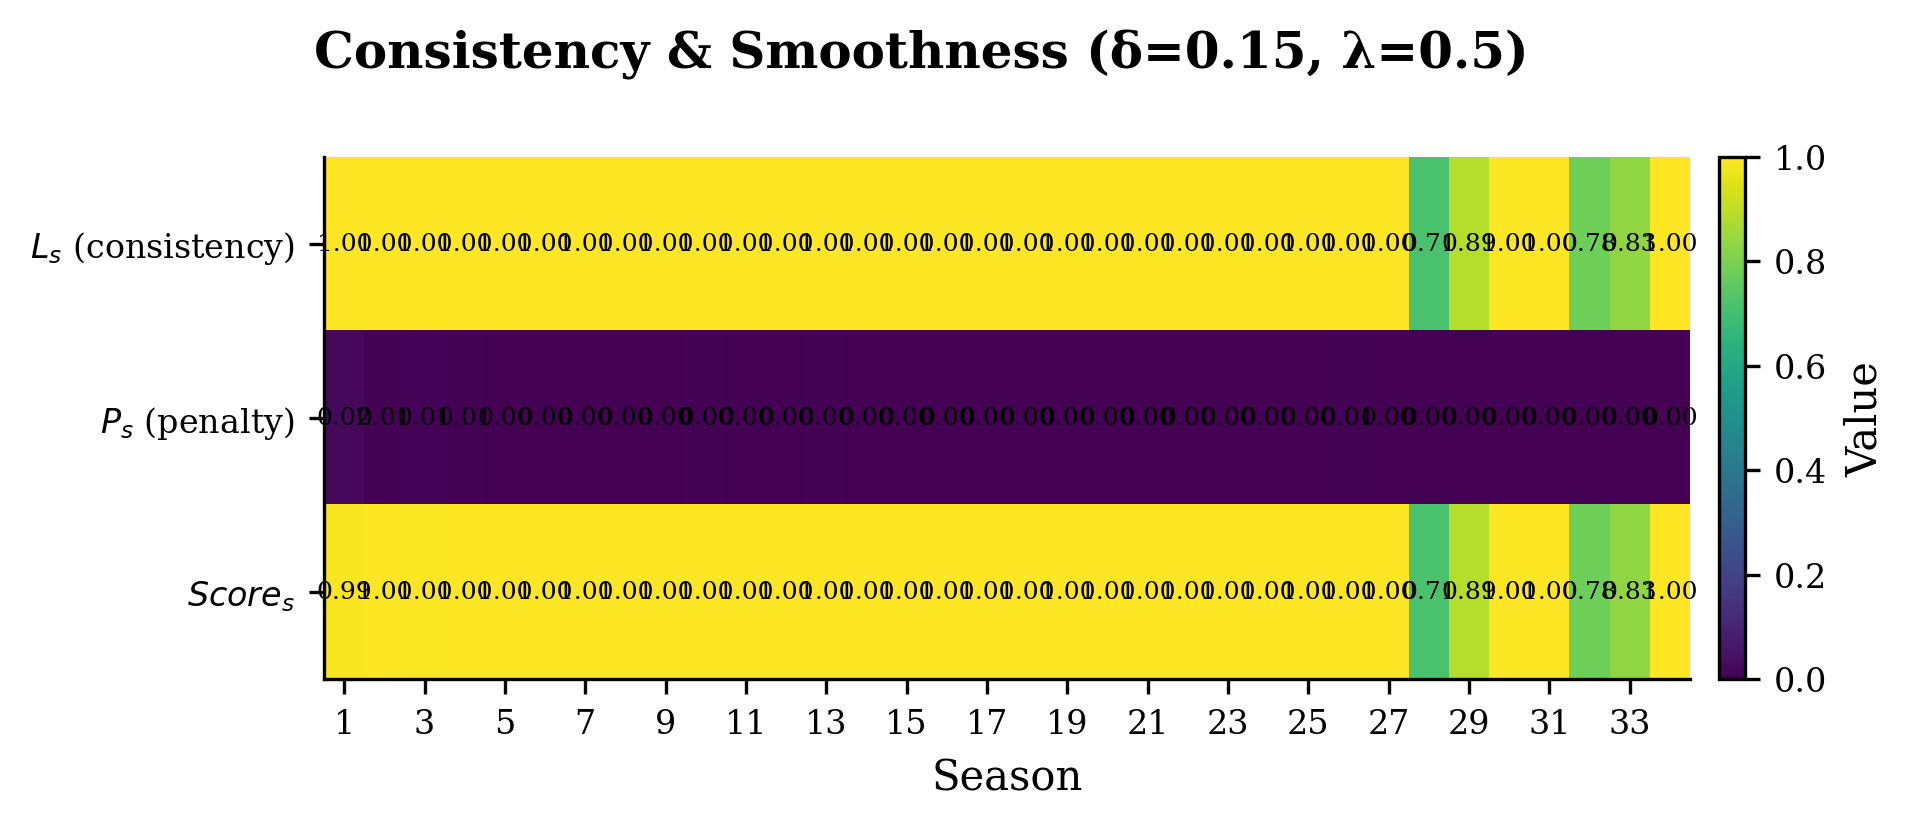

Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task1-q1_consistency_with_smoothness.pdf
Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task1-q1_consistency_with_smoothness.pdf


In [4]:
plot_consistency_smoothness(DATA_CSV, OUT_PDF)
print("Saved:", OUT_PDF)
